In [2]:
import ozy 
import numpy as np
import glob
import os
import pandas as pd
import matplotlib.pyplot as plt

directory = '/mnt/extraspace/currodri/newhorizon_rar/00925_100PerCentPurity/'
ozy_files = []
for filename in glob.glob(os.path.join(directory, '*.hdf5')):
    ozy_files.append(filename)

ozy_file = ozy_files[0]





   ___                                           _  _             
  /___\ ____ _   _  _ __ ___    __ _  _ __    __| |(_)  __ _  ___ 
 //  //|_  /| | | || '_ ` _ \  / _` || '_ \  / _` || | / _` |/ __|
/ \_//  / / | |_| || | | | | || (_| || | | || (_| || || (_| |\__ \
\___/  /___| \__, ||_| |_| |_| \__,_||_| |_| \__,_||_| \__,_||___/
             |___/                                                

   (C) 2021 F. Rodriguez Montero
   Version 0.2.dev1



Galaxy 11 is weird in bin 6


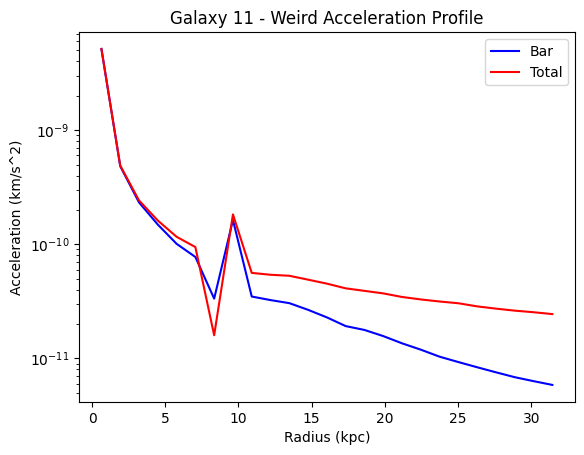

Galaxy 92 is weird in bin 4
Galaxy 92 is weird in bin 5
Galaxy 92 is weird in bin 6
Galaxy 92 is weird in bin 7
Galaxy 92 is weird in bin 8
Galaxy 92 is weird in bin 9
Galaxy 92 is weird in bin 10


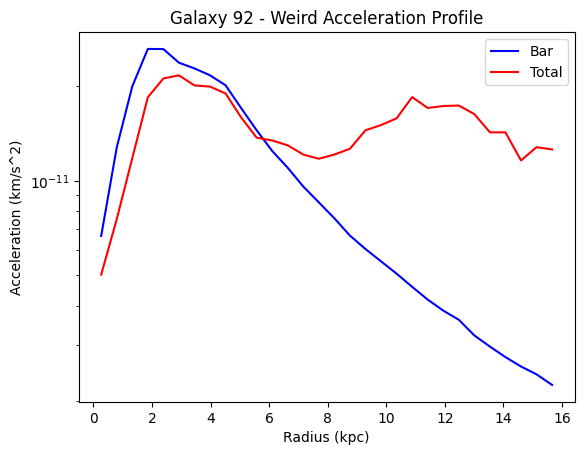

Galaxy 964 is weird in bin 23


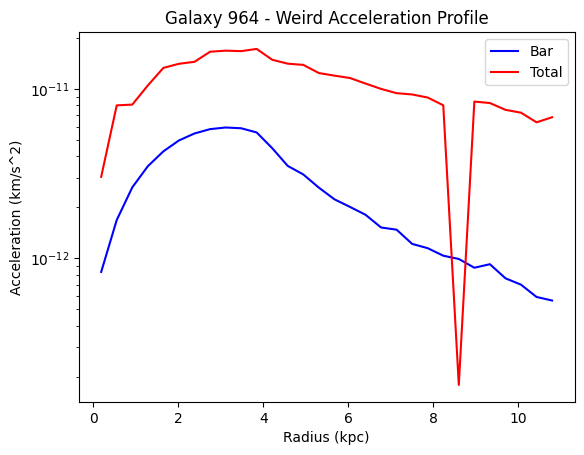

Galaxy 999 is weird in bin 12


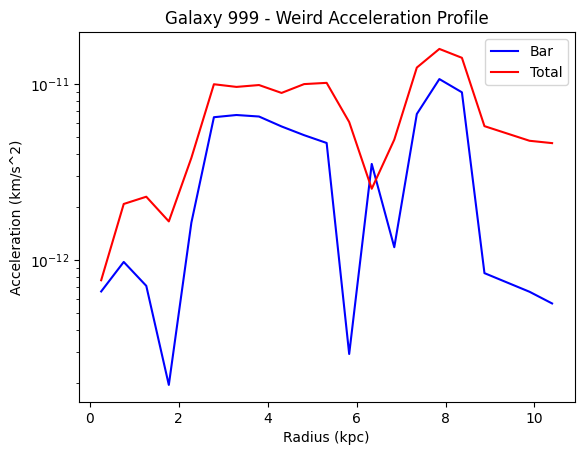

4
Weird galaxies: [11, 92, 964, 999]


In [8]:
directory = '/mnt/users/darnej/MPhys/pytree_results/'

gals = np.loadtxt('Chosen_galaxies.txt')

counter = 0

weird_gals = []

for gal in gals:

    gal = int(gal)

    files = glob.glob(os.path.join(directory, 'pytree_results_' + str(gal) + '.csv'))

    file = files[0]

    df = pd.read_csv(file)

    g_bar = df['mean_a_r_py'].values
    g_tot = df['mean_a_r_total_py'].values
    radial = df['mean_r'].values

    mask = g_bar == 0

    g_bar = g_bar[~mask]
    g_tot = g_tot[~mask]
    radial = radial[~mask]

    plot = False

    for i in range(len(radial)):
        if g_bar[i] > g_tot[i] and i not in [0,1,2,3]:
            print(f'Galaxy {gal} is weird in bin {i}')
            plot = True
        
    if plot:
        plt.plot(radial, g_bar, label='Bar', color='blue')
        plt.plot(radial, g_tot, label='Total', color='red')
        plt.xlabel('Radius (kpc)')
        plt.ylabel('Acceleration (km/s^2)')
        plt.yscale('log')
        plt.title(f'Galaxy {gal} - Weird Acceleration Profile')
        plt.legend()
        plt.show()
        counter += 1
        weird_gals.append(gal)
        

print(counter)
print('Weird galaxies:', weird_gals)


